## 编码器-解码器架构

机器翻译是序列转换模型的一个核心问题， 其输入和输出都是长度可变的序列。 为了处理这种类型的输入和输出， 我们可以设计一个包含两个主要组件的架构： 第一个组件是一个编码器（encoder）： 它接受一个长度可变的序列作为输入， 并将其转换为具有固定形状的编码状态。 第二个组件是解码器（decoder）： 它将固定形状的编码状态映射到长度可变的序列。 这被称为编码器-解码器（encoder-decoder）架构:

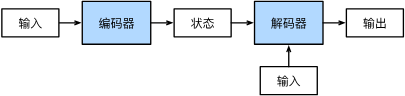

### 编码器

在编码器接口中，我们只指定长度可变的序列作为编码器的输入X。 任何继承这个Encoder基类的模型将完成代码实现。

In [1]:
from torch import nn

class Encoder(nn.Module):
    """编码器-解码器架构的基本编码器接口"""
    def __init__(self,**kwargs):
        super(Encoder, self).__init__(**kwargs)

    def forward(self,X,**kwargs):
        raise NotImplementedError

### 解码器

在下面的解码器接口中，我们新增一个init_state函数， 用于将编码器的输出（enc_outputs）转换为编码后的状态。 注意，此步骤可能需要额外的输入，例如：输入序列的有效长度，为了逐个地生成长度可变的词元序列， 解码器在每个时间步都会将输入 （例如：在前一时间步生成的词元）和编码后的状态 映射成当前时间步的输出词元。

In [2]:
class Decoder(nn.Module):
    """编码器-解码器架构的基本解码器接口"""
    def __init__(self,**kwargs):
        super(Decoder, self).__init__(**kwargs)
    
    def init_state(self,enc_outputs,**kwargs):
        raise NotImplementedError
    
    def forward(self,enc_outputs,**kwargs):
        raise NotImplementedError

### 合并编码器和解码器
“编码器－解码器”体系架构中的术语状态 会启发人们使用具有状态的神经网络来实现该架构。

In [3]:
class EncoderDecoder(nn.Module):
    """编码器－解码器架构的基类"""
    def __init__(self, encoder, decoder, **kwargs):
        super(EncoderDecoder, self).__init__(**kwargs)
        self.encoder = encoder
        self.decoder = decoder
    
    def forward(self, enc_X,dec_X, **kwargs):
        enc_outputs = self.encoder(enc_X, **kwargs)
        dec_outputs = self.decoder(dec_X, enc_outputs, **kwargs)
        return enc_outputs, dec_outputs

## 小结

“编码器－解码器”架构可以将长度可变的序列作为输入和输出，因此适用于机器翻译等序列转换问题。

编码器将长度可变的序列作为输入，并将其转换为具有固定形状的编码状态。

解码器将具有固定形状的编码状态映射为长度可变的序列。